In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import getting_threshold_genes as gtg
from sklearn.model_selection import train_test_split
import model as m
import divide_bins as divide
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef
from ydata_profiling import ProfileReport
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score



2024-05-02 15:26:00.245784: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-02 15:26:00.248250: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-02 15:26:00.281895: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-02 15:26:00.281945: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-02 15:26:00.283081: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

# Compleate pipeline



## Data
We used reCombat for RNAseq and microarray independently one form another.

In [2]:
rnaSeq_origial =  pd.read_csv('Data/RNAseq_abundances_adjusted_recombat.csv')


In [3]:
seq_metadata_path = "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/All_rna_samples_metadata_edit.csv"
seq_metadata = pd.read_csv(seq_metadata_path)
rnaSeq_origial= pd.merge(rnaSeq_origial, seq_metadata, on='Sample', how='inner')


We can see the distribution of the 

## Ridge regression for first filter

Prevously, I go the filtered genes for 

### Getting selected genes
Here I am using the ridge regression getting as threshold the genes that are higher that the second derivate of the approximated curve of the scores.
In feature_selection_all.ipnb, I ran the Ridge in all the data for both microRNA and RNAseq.
for example:
```dataset=all_microarray_data
result = get_feature_from_class(dataset)
result.to_csv("Results/feature_selection/microarray/ridge_L2_0/all_feature_selection.csv")
```


The ridge evaluation is collected here

In [4]:

rnaseq_path = f"Results/feature_selection/RNAseq/ridge_L2_0/RNAseq_All_abundances_adjusted_feature_selection.csv"



In [5]:
df = gtg.get_df(rnaseq_path, alpha=0.05)
rnaseq_genes = df["Ensembl"]
len(rnaseq_genes)

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/getting_threshold_genes.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if gene_rank_df.iloc[0][1] == "coef":


5507

In [6]:
del df

So we got 241 genes for RNAseq and 112 for microRNA

### Filter by the genes

In [7]:
rnaseq_genes = rnaseq_genes.to_list()

rnaseq_genes.append("Age")
rnaseq_genes.append("Experiment")
rnaseq_genes.append("Status")
rnaseq_genes.append("Sex")
rnaseq_genes.append("Sample")

rnaSeq_filteres = rnaSeq_origial[rnaseq_genes]


### Separate test and train datasets

Here I will use prefix seq to say RNAse and arr to say microarray. I am using a test_size of 50 because I will use smote to increase the data for the training.

In [8]:
seq_X_train, seq_X_test, seq_y_train, seq_y_test, seq_z_train, seq_z_test = m.divide_test_train_dataset(rnaSeq_filteres, test_size=0.4)


### Divide the ages into bins

In [9]:
seq_age_ranges = divide.get_age_distribution(seq_y_train, age_ranges=[18, 25, 35, 45,70,72,  100])


In [10]:
seq_categories = [18, 25, 35, 45, 70, 72, 90]





In [11]:
seq_y_train_cat = seq_y_train.apply(lambda x: divide.assign_age_group(x, seq_age_ranges))

### Balanced the data using smote

In [12]:
dataset = pd.DataFrame(seq_X_train)
dataset["Age"] = seq_y_train_cat
result = divide.get_feature_SMOTE(dataset, is_categorical=True)
seq_X_train_cat_a = pd.DataFrame(result[0])
seq_y_train_cat_a = result[1]

Class distribution before SMOTE: Counter({'70-72': 46, '25-35': 30, '72-100': 27, '18-25': 25, '45-70': 24, '35-45': 10})
Class distribution after SMOTE: Counter({'70-72': 46, '72-100': 46, '45-70': 46, '35-45': 46, '18-25': 46, '25-35': 46})


#### Add noise to the data

In [13]:
noise = np.random.normal(0.01, 0.01, seq_X_train_cat_a.shape)  # Generate random noise with mean 0 and standard deviation 1
#seq_X_train_cat_a = seq_X_train_cat_a + noise


In [14]:

seq_y_train_a = pd.Series(seq_y_train_cat_a).str.split('-')
seq_y_train_a = seq_y_train_a.apply(lambda x: (int(x[0]) + int(x[1])) / 2)

y_noise = np.random.normal(0, 2, seq_y_train_a.shape)
seq_y_train_a = seq_y_train_a + y_noise
seq_y_train_a = seq_y_train_a.round(0)


Now, we have for microarray and rna seq, an augmented training dataset.

### Normalizing the data

First we take a look on the data. And proceed with the normalization.
NOTE: I have to re run the RIdge (Maybe) because this step should be before

In [15]:
# normalize the data z score
seq_normalize_X_train, seq_scaler = m.normalize_train_data(seq_X_train_cat_a)

### Preparing the model

Before running the model, we look for the best parameter

First we define the optimization function like the following

In [16]:
seq_parms = {'iterations': 462, 'learning_rate': 0.0510, 'depth': 5}



### Train the model
For this, we will take catBoost since is the one that worked the best

#### RNAseq


In [61]:
dataset = pd.DataFrame(seq_normalize_X_train)
dataset.columns = seq_X_train_cat_a.columns
dataset["Age"] = seq_y_train_a


#dataset = pd.DataFrame(seq_X_train)
#dataset.columns = rnaseq_genes[:-2]
#dataset["Age"] = seq_y_train

X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)
#random_strength

# Initialize CatBoostClassifier
seq_regressor = CatBoostRegressor(iterations=4000,
                                  learning_rate=0.005,
                                  depth=4,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  random_strength=0.7,
                                  ) 

# Fit the model
seq_regressor.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)



MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 22.9222404	test: 22.3691335	best: 22.3691335 (0)	total: 163ms	remaining: 10m 50s
1:	learn: 22.8831752	test: 22.3374787	best: 22.3374787 (1)	total: 334ms	remaining: 11m 7s
2:	learn: 22.8459437	test: 22.3075119	best: 22.3075119 (2)	total: 516ms	remaining: 11m 27s
3:	learn: 22.8058712	test: 22.2776246	best: 22.2776246 (3)	total: 675ms	remaining: 11m 14s
4:	learn: 22.7650746	test: 22.2541619	best: 22.2541619 (4)	total: 851ms	remaining: 11m 19s
5:	learn: 22.7217877	test: 22.2200146	best: 22.2200146 (5)	total: 1.02s	remaining: 11m 20s
6:	learn: 22.6813857	test: 22.1800131	best: 22.1800131 (6)	total: 1.19s	remaining: 11m 19s
7:	learn: 22.6379498	test: 22.1614361	best: 22.1614361 (7)	total: 1.36s	remaining: 11m 20s
8:	learn: 22.5919158	test: 22.1261748	best: 22.1261748 (8)	total: 1.53s	remaining: 11m 18s
9:	learn: 22.5580112	test: 22.1167461	best: 22.1167461 (9)	total: 1.7s	remaining: 11m 18s
10:	learn: 22.5164614	test: 22.0837296	best: 22.0837296 (10)	total: 1.87s	remaining: 11m 17s

In [62]:
# Make predictions
y_pred = seq_regressor.predict(X_test)

# Evaluate mean squared error
seq_mse = mean_squared_error(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
seq_mse


143.951908626434

#### Plotting results

We have some pre desing plots for the results.

In [63]:
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))

/tmp/ipykernel_86279/659211106.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


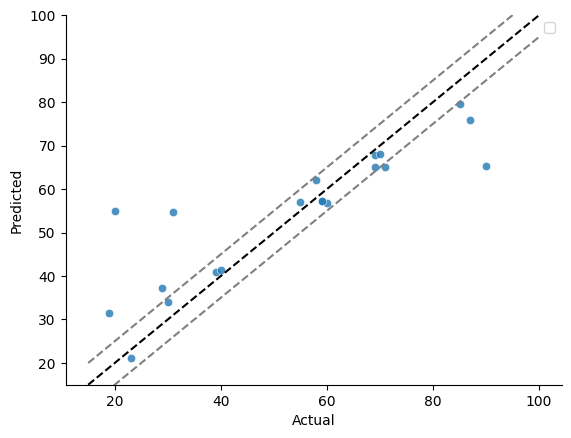

In [64]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [20, 105], color='gray', linestyle='--')
plt.plot([15, 100], [10, 95], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

#### Reviewing with original (not augmented) data

In [65]:
seq_X_train_normalize = seq_scaler.transform(seq_X_train)
y_pred = seq_regressor.predict(seq_X_train_normalize)
seq_mse = mean_squared_error(seq_y_train, y_pred)
seq_mse


41.66746107593393

     Actual  Predicted Actual_round Predicted_round Experiment
52     71.0  71.851425        70-72           70-72  GSE157585
147    77.0  79.479273       72-100          72-100  GSE167186
254    58.0  56.839430        45-70           45-70  GSE129643
51     71.0  65.129816        70-72           45-70  GSE157585
6      42.0  40.014509        35-45           35-45  GSE164471
..      ...        ...          ...             ...        ...
257    67.0  56.087648        45-70           45-70  GSE129643
249    45.0  58.316865        45-70           45-70  GSE129643
21     83.0  80.145696       72-100          72-100  GSE164471
181    67.0  63.142887        45-70           45-70  GSE167186
49     85.0  78.946684       72-100          72-100  GSE152558

[162 rows x 5 columns]


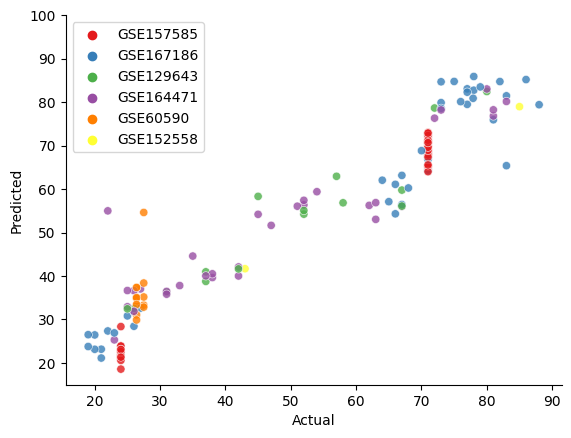

In [66]:

seq_results = pd.DataFrame({'Actual': seq_y_train, 'Predicted': y_pred})
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
m.plot_results(results=seq_results, labels=seq_z_train)

#### Reviewing with compleatly untouch data

In [67]:
seq_normalize_X_test = seq_scaler.transform(seq_X_test)

print(len(seq_normalize_X_test))

108


In [68]:
y_pred = seq_regressor.predict(seq_normalize_X_test)
len(y_pred)

108

In [69]:

# Evaluate mean squared error
seq_mse = mean_squared_error(seq_y_test, y_pred)
seq_mse

288.0429244578708

In [70]:
seq_results = pd.DataFrame({'Actual': seq_y_test, 'Predicted': y_pred})
seq_results["Actual_round"] = seq_results["Actual"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_results["Predicted_round"] = seq_results["Predicted"].apply(lambda x: divide.assign_age_group(x, seq_age_ranges))



In [71]:
seq_z_test

,Age,Experiment,Status,Sex,Sample
125,24.0,GSE157585,Healthy,NaN,SRR12604218
174,18.0,GSE167186,Healthy,NaN,SRR13759023
176,23.0,GSE167186,Healthy,NaN,SRR13759025
232,26.4,GSE60590,untrained,female,SRR1555206
100,71.0,GSE157585,Healthy,NaN,SRR12604184
...,...,...,...,...,...
65,71.0,GSE157585,Healthy,NaN,SRR12604112
162,23.0,GSE167186,Healthy,NaN,SRR13759011
17,72.0,GSE164471,Healthy,male,SRR13388749
74,71.0,GSE157585,Healthy,NaN,SRR12604127


     Actual  Predicted Actual_round Predicted_round Experiment
125    24.0  30.548444        18-25           25-35  GSE157585
174    18.0  45.870913        18-25           45-70  GSE167186
176    23.0  39.822452        18-25           35-45  GSE167186
232    26.4  58.832381        25-35           45-70   GSE60590
100    71.0  71.535933        70-72           70-72  GSE157585
..      ...        ...          ...             ...        ...
65     71.0  65.811611        70-72           45-70  GSE157585
162    23.0  52.222003        18-25           45-70  GSE167186
17     72.0  50.985346       72-100           45-70  GSE164471
74     71.0  67.802180        70-72           45-70  GSE157585
179    71.0  50.328037        70-72           45-70  GSE167186

[108 rows x 5 columns]


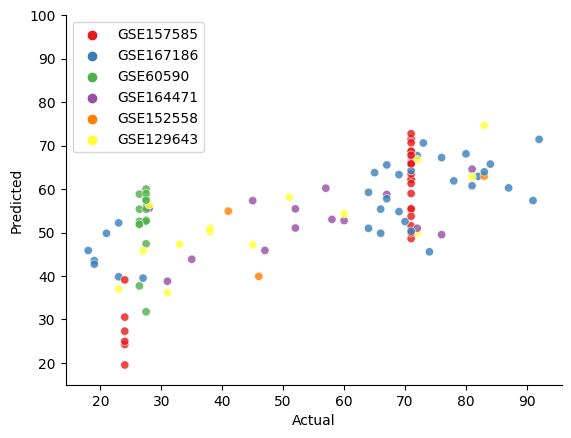

In [72]:
m.plot_results(results=seq_results, labels=seq_z_test)

/tmp/ipykernel_86279/1353697775.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


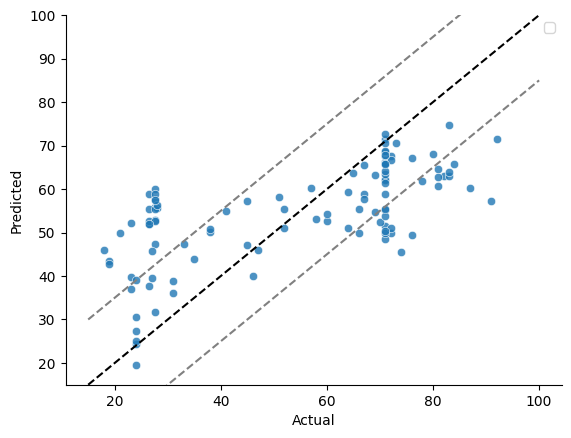

In [73]:
# Your existing scatter plot code
sns.scatterplot(x='Actual', y='Predicted', data=seq_results, palette='Set1', alpha=0.8, edgecolor='w')

# Plotting the diagonal line
plt.plot([15, 100], [15, 100], color='black', linestyle='--')

# Plotting lines parallel to the diagonal line
plt.plot([15, 100], [30, 115], color='gray', linestyle='--')
plt.plot([15, 100], [0, 85], color='gray', linestyle='--')

# Customizing the plot
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

### Feaures

In [74]:
explainer = shap.Explainer(seq_regressor)
seq_test_df = pd.DataFrame(seq_normalize_X_test)
seq_test_df.columns = seq_X_train_cat_a.columns
seq_test_df["Age"]= seq_y_test
shap_values = explainer.shap_values(seq_test_df)
importance = seq_regressor.get_feature_importance()
feature_imporance_df = pd.DataFrame(importance, index=seq_X_train_cat_a.columns, columns=["importance"])
feature_imporance_df=feature_imporance_df[feature_imporance_df["importance"] > 0]
feature_imporance_df = feature_imporance_df.sort_values(by="importance", ascending=False)


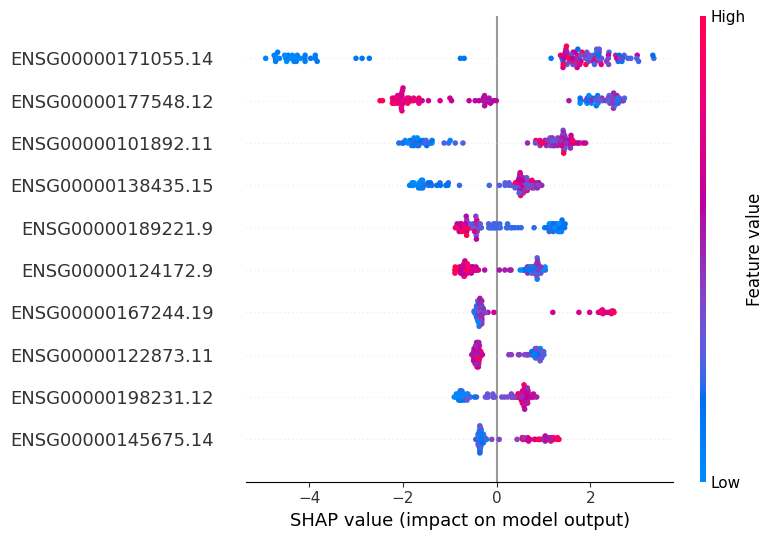

In [75]:
shap.summary_plot(shap_values, seq_test_df, max_display=10)


In [76]:
feature_imporance_df.to_csv("/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Results/master/feature_selection/RNAseq_shap_2.csv", index=True)

# Double filter


In [77]:
filter_genes = feature_imporance_df[feature_imporance_df["importance"] > 0.1].index
filter_genes = filter_genes.to_list()
len(filter_genes)

143

In [78]:
dataset = pd.DataFrame(seq_normalize_X_train)
dataset.columns = seq_X_train_cat_a.columns
dataset = dataset[filter_genes]
dataset["Age"] = seq_y_train_a


#dataset = pd.DataFrame(seq_X_train)
#dataset.columns = rnaseq_genes[:-2]
#dataset["Age"] = seq_y_train

X_train, X_test, y_train, y_test, _, _ = m.divide_test_train_dataset(dataset, test_size=0.07)

y_train = pd.Series(y_train).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
y_test = pd.Series(y_test).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
# Initialize CatBoostClassifier
seq_classifier = CatBoostClassifier(iterations=4000,
                                  learning_rate=0.005,
                                  depth=3,
                                  random_state=42,
                                  verbose=1,
                                  od_type='Iter',
                                  od_wait=50,
                                  penalties_coefficient=50,
                                  l2_leaf_reg=5,  # Adjust regularization
                                  ) 

# Fit the model
seq_classifier.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True, plot=True)



MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.9429370	test: 1.9423928	best: 1.9423928 (0)	total: 8.68ms	remaining: 34.7s
1:	learn: 1.9403935	test: 1.9401537	best: 1.9401537 (1)	total: 22.5ms	remaining: 44.9s
2:	learn: 1.9369497	test: 1.9367773	best: 1.9367773 (2)	total: 36.4ms	remaining: 48.5s
3:	learn: 1.9341489	test: 1.9343559	best: 1.9343559 (3)	total: 45.6ms	remaining: 45.5s
4:	learn: 1.9309947	test: 1.9318005	best: 1.9318005 (4)	total: 58.9ms	remaining: 47.1s
5:	learn: 1.9290438	test: 1.9302551	best: 1.9302551 (5)	total: 74.8ms	remaining: 49.8s
6:	learn: 1.9258597	test: 1.9277335	best: 1.9277335 (6)	total: 86.7ms	remaining: 49.4s
7:	learn: 1.9230985	test: 1.9252607	best: 1.9252607 (7)	total: 96.4ms	remaining: 48.1s
8:	learn: 1.9200813	test: 1.9226519	best: 1.9226519 (8)	total: 107ms	remaining: 47.6s
9:	learn: 1.9178379	test: 1.9210476	best: 1.9210476 (9)	total: 117ms	remaining: 46.8s
10:	learn: 1.9157294	test: 1.9194290	best: 1.9194290 (10)	total: 127ms	remaining: 46.1s
11:	learn: 1.9134637	test: 1.9177775	best: 1

In [79]:
y_pred = seq_classifier.predict(X_test)

# Evaluate mean squared error
seq_mcc = matthews_corrcoef(y_test, y_pred)
seq_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.T[0]})
seq_mcc

0.7104030547600328

In [80]:
c_y_test = seq_results["Actual"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = seq_results["Predicted"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
seq_confusion_matrix

array([[2, 0, 0, 1, 0, 0],
       [0, 3, 0, 0, 0, 0],
       [0, 0, 2, 0, 0, 0],
       [0, 0, 0, 5, 0, 2],
       [0, 0, 0, 0, 0, 2],
       [0, 0, 0, 0, 0, 3]])

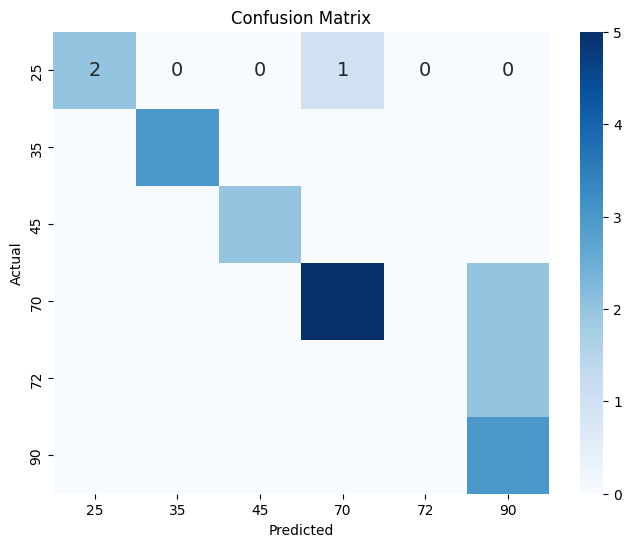

In [81]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(seq_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=seq_categories[1:], yticklabels=seq_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [82]:
seq_normalize_X_test_filter = pd.DataFrame(seq_normalize_X_test)
seq_normalize_X_test_filter.columns = rnaseq_genes[:-5]


Source data

 I WAS HERE!!!!!!!!!!!!!!!!!!!!
 The mcc of the source data make no sense, find the error

In [83]:
seq_X_train_normalize = seq_scaler.transform(seq_X_train)




In [84]:
seq_normalize_X_test_filter = pd.DataFrame(seq_X_train_normalize)
seq_normalize_X_test_filter.columns = rnaseq_genes[:-5]
seq_normalize_X_test_filter= seq_normalize_X_test_filter[filter_genes]
seq_normalize_X_test_filter.shape

(162, 143)

In [85]:
y_pred = seq_classifier.predict(seq_normalize_X_test_filter)

In [86]:
len(y_pred.T[0])

162

In [87]:
seq_y_train.shape

(162,)

In [88]:


seq_results = pd.DataFrame({'Actual': seq_y_train, 'Predicted': y_pred.T[0]})
seq_y_test_c = pd.Series(seq_y_train).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
seq_mcc = matthews_corrcoef(seq_y_test_c, y_pred.T[0])
seq_mcc

0.8175385640493645

In [89]:
seq_results

,Actual,Predicted
52,71.0,70-72
147,77.0,72-100
254,58.0,45-70
51,71.0,72-100
6,42.0,35-45
...,...,...
257,67.0,45-70
249,45.0,45-70
21,83.0,72-100
181,67.0,45-70


In [90]:
seq_results_return = seq_results.copy()
seq_results_return["Predicted"] = seq_results_return["Predicted"].str.split('-')
seq_results_return["Predicted"] = seq_results_return["Predicted"].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
noise = np.random.normal(2, 2, len(seq_results_return))
seq_results_return["Predicted"] = seq_results_return["Predicted"] + noise



     Actual  Predicted Experiment
52     71.0  71.588238  GSE157585
147    77.0  85.467084  GSE167186
254    58.0  62.683031  GSE129643
51     71.0  92.927498  GSE157585
6      42.0  41.697989  GSE164471
..      ...        ...        ...
257    67.0  57.036750  GSE129643
249    45.0  58.528281  GSE129643
21     83.0  90.443720  GSE164471
181    67.0  61.184550  GSE167186
49     85.0  87.486845  GSE152558

[162 rows x 3 columns]


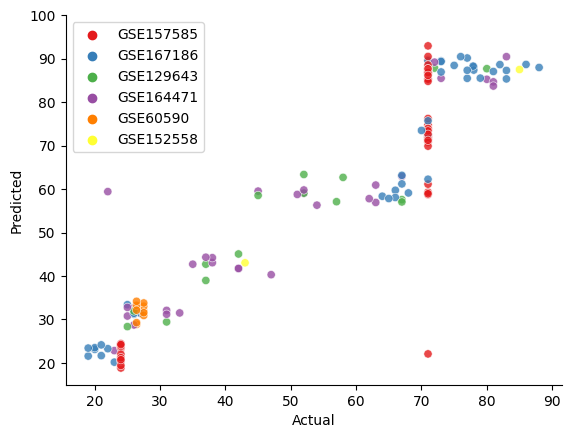

In [91]:
m.plot_results(results=seq_results_return, labels=seq_z_train)

     Actual  Predicted Experiment      Status
52     71.0  71.588238  GSE157585     Healthy
147    77.0  85.467084  GSE167186  Sarcopenia
254    58.0  62.683031  GSE129643     Healthy
51     71.0  92.927498  GSE157585     Healthy
6      42.0  41.697989  GSE164471     Healthy
..      ...        ...        ...         ...
257    67.0  57.036750  GSE129643     Healthy
249    45.0  58.528281  GSE129643     Healthy
21     83.0  90.443720  GSE164471     Healthy
181    67.0  61.184550  GSE167186     Healthy
49     85.0  87.486845  GSE152558     Healthy

[162 rows x 4 columns]


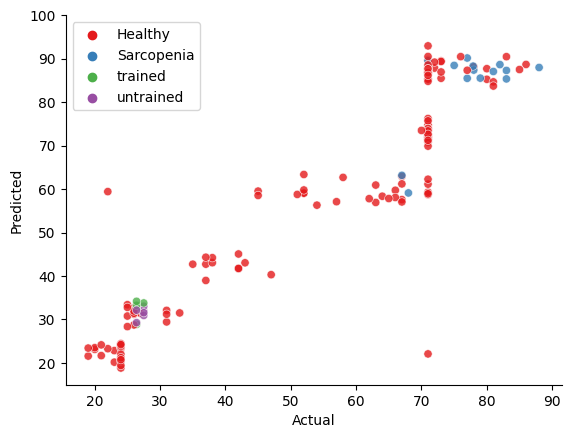

In [92]:
m.plot_results(results=seq_results_return, labels=seq_z_train, print_label="Status")

In [93]:
seq_results_return_df = pd.DataFrame(seq_results_return)
seq_results_return_df.merge(seq_z_train)
seq_results_return_df["Status"] = seq_z_train["Status"]
seq_results_return_df["Sample"] = seq_z_train["Sample"]
seq_results_return_df["Sex"] = seq_z_train["Sex"]
seq_results_return_df["Difference"] = abs(seq_results_return_df["Actual"] - seq_results_return_df["Predicted"])
seq_results_return_df = seq_results_return_df.sort_values(by="Difference", ascending=False)
seq_results_return_df[seq_results_return_df["Difference"]>13]

,Actual,Predicted,Experiment,Status,Sample,Sex,Difference
80,71.0,22.086488,GSE157585,Healthy,SRR12604140,NaN,48.913512
22,22.0,59.410788,GSE164471,Healthy,SRR13388754,male,37.410788
51,71.0,92.927498,GSE157585,Healthy,SRR12604092,NaN,21.927498
71,71.0,90.486274,GSE157585,Healthy,SRR12604124,NaN,19.486274
93,71.0,89.696201,GSE157585,Healthy,SRR12604163,NaN,18.696201
185,71.0,89.509735,GSE167186,Sarcopenia,SRR13759035,NaN,18.509735
60,71.0,88.532252,GSE157585,Healthy,SRR12604103,NaN,17.532252
42,72.0,89.186577,GSE164471,Healthy,SRR13388781,male,17.186577
105,71.0,88.139828,GSE157585,Healthy,SRR12604189,NaN,17.139828
55,71.0,87.684814,GSE157585,Healthy,SRR12604096,NaN,16.684814


In [94]:
len(seq_results_return_df[seq_results_return_df["Difference"]>13])/len(seq_results_return_df)

0.19135802469135801

Unseen data

In [95]:
# Make predictions
X_test_filter = pd.DataFrame(seq_X_test)
X_test_filter.columns = rnaseq_genes[:-5]
X_test_filter = seq_scaler.transform(X_test_filter)
X_test_filter = pd.DataFrame(X_test_filter)
X_test_filter.columns = rnaseq_genes[:-5]
X_test_filter = X_test_filter[filter_genes]


In [96]:
#normalize_seq_X_test = seq_scaler.transform(seq_X_test)
y_pred = seq_classifier.predict(X_test_filter)
seq_y_test_c = pd.Series(seq_y_test).apply(lambda x: divide.assign_age_group(x, seq_age_ranges))
# Evaluate mean squared error
seq_mcc = matthews_corrcoef(seq_y_test_c, y_pred)
seq_results = pd.DataFrame({'Actual': seq_y_test_c, 'Predicted': y_pred.T[0]})
seq_mcc

0.34079103998868027

In [97]:
c_y_test = seq_results["Actual"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
c_y_pred = seq_results["Predicted"]#.apply(lambda x: divide.assign_age_group(x, arr_age_ranges))
seq_confusion_matrix = confusion_matrix(c_y_test, c_y_pred)
seq_confusion_matrix

array([[ 6,  2,  0,  5,  0,  0],
       [ 1, 13,  0,  4,  0,  5],
       [ 0,  2,  1,  1,  0,  0],
       [ 1,  1,  0, 14,  0,  5],
       [ 1,  3,  0,  0,  4, 18],
       [ 0,  0,  0,  9,  1, 11]])

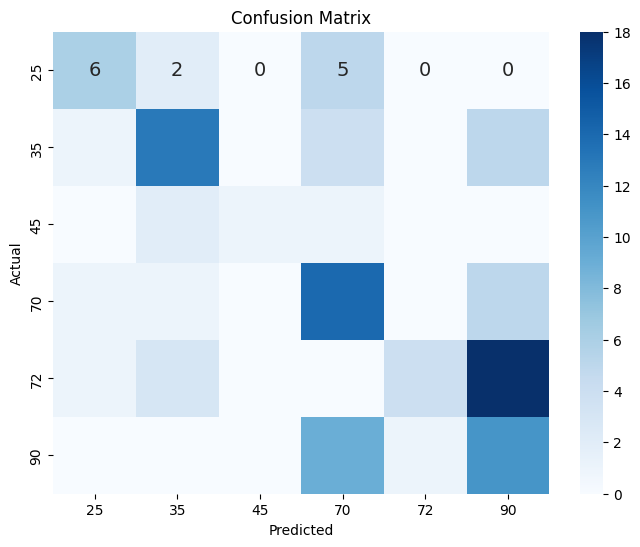

In [98]:

# Evaluate mean squared error
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(seq_confusion_matrix, cmap='Blues', annot_kws={'size': 14},
 xticklabels=seq_categories[1:], yticklabels=seq_categories[1:], fmt='d', annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

     Actual  Predicted Experiment
125    24.0  23.769887  GSE157585
174    18.0  61.123556  GSE167186
176    23.0  56.700763  GSE167186
232    26.4  35.426995   GSE60590
100    71.0  90.621518  GSE157585
..      ...        ...        ...
65     71.0  87.899151  GSE157585
162    23.0  60.496541  GSE167186
17     72.0  58.417209  GSE164471
74     71.0  87.180130  GSE157585
179    71.0  34.465067  GSE167186

[108 rows x 3 columns]


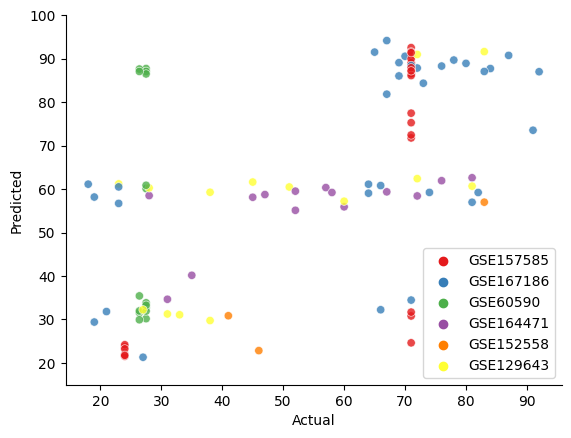

In [99]:
seq_results_return = seq_results.copy()
seq_results_return["Actual"]  = seq_y_test
seq_results_return["Predicted"] = seq_results_return["Predicted"].str.split('-')
seq_results_return["Predicted"] = seq_results_return["Predicted"].apply(lambda x: (int(x[0]) + int(x[1])) / 2)
noise = np.random.normal(2, 2, len(seq_results_return))
seq_results_return["Predicted"] = seq_results_return["Predicted"] + noise
m.plot_results(results=seq_results_return, labels=seq_z_test)

     Actual  Predicted Experiment     Status
125    24.0  23.769887  GSE157585    Healthy
174    18.0  61.123556  GSE167186    Healthy
176    23.0  56.700763  GSE167186    Healthy
232    26.4  35.426995   GSE60590  untrained
100    71.0  90.621518  GSE157585    Healthy
..      ...        ...        ...        ...
65     71.0  87.899151  GSE157585    Healthy
162    23.0  60.496541  GSE167186    Healthy
17     72.0  58.417209  GSE164471    Healthy
74     71.0  87.180130  GSE157585    Healthy
179    71.0  34.465067  GSE167186    Healthy

[108 rows x 4 columns]


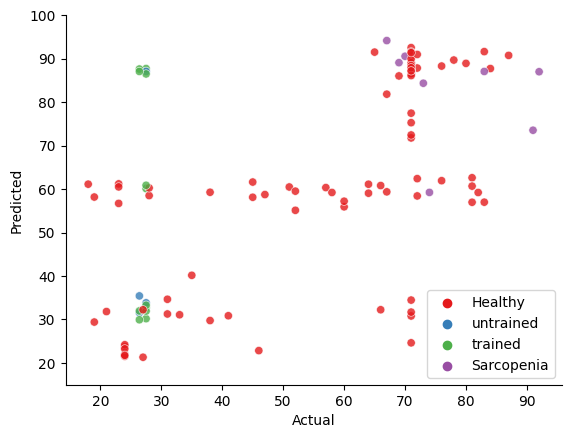

In [100]:
m.plot_results(results=seq_results_return, labels=seq_z_test, print_label="Status")

     Actual  Predicted Experiment     Status     Sex
125    24.0  23.769887  GSE157585    Healthy     NaN
174    18.0  61.123556  GSE167186    Healthy     NaN
176    23.0  56.700763  GSE167186    Healthy     NaN
232    26.4  35.426995   GSE60590  untrained  female
100    71.0  90.621518  GSE157585    Healthy     NaN
..      ...        ...        ...        ...     ...
65     71.0  87.899151  GSE157585    Healthy     NaN
162    23.0  60.496541  GSE167186    Healthy     NaN
17     72.0  58.417209  GSE164471    Healthy    male
74     71.0  87.180130  GSE157585    Healthy     NaN
179    71.0  34.465067  GSE167186    Healthy     NaN

[108 rows x 5 columns]


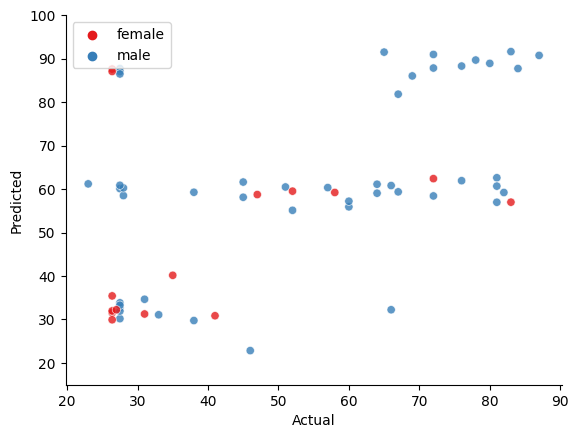

In [101]:
m.plot_results(results=seq_results_return, labels=seq_z_test, print_label="Sex")

In [102]:
seq_results_return_df = pd.DataFrame(seq_results_return)
seq_results_return_df.merge(seq_z_test)
seq_results_return_df["Status"] = seq_z_test["Status"]
seq_results_return_df["Sample"] = seq_z_test["Sample"]
seq_results_return_df["Sex"] = seq_z_test["Sex"]
seq_results_return_df["Difference"] = abs(seq_results_return_df["Actual"] - seq_results_return_df["Predicted"])
seq_results_return_df = seq_results_return_df.sort_values(by="Difference", ascending=False)
seq_results_return_df[seq_results_return_df["Difference"]>13]

,Actual,Predicted,Experiment,Status,Sex,Sample,Difference
210,26.4,87.608391,GSE60590,trained,female,SRR1555180,61.208391
218,26.4,87.046011,GSE60590,trained,female,SRR1555192,60.646011
219,27.5,87.714684,GSE60590,trained,male,SRR1555193,60.214684
216,27.5,87.061781,GSE60590,untrained,male,SRR1555190,59.561781
229,27.5,86.473180,GSE60590,trained,male,SRR1555203,58.973180
79,71.0,24.633926,GSE157585,Healthy,NaN,SRR12604139,46.366074
174,18.0,61.123556,GSE167186,Healthy,NaN,SRR13759023,43.123556
64,71.0,30.809856,GSE157585,Healthy,NaN,SRR12604111,40.190144
109,71.0,31.699825,GSE157585,Healthy,NaN,SRR12604199,39.300175
172,19.0,58.164071,GSE167186,Healthy,NaN,SRR13759021,39.164071


In [103]:
len(seq_results_return_df[seq_results_return_df["Difference"]>15])/len(seq_results_return_df)

0.48148148148148145